# Cenário 5: Avaliação de Risco e Segurança Pública (Criminologia / Justiça)

Seminário de Viés (P1). Enunciado: Sub representar intencionalmente um grupo étnico/racial no conjunto de treinamento 
para induzir taxas de erro díspares entre os grupos

Dados: COMPAS (ProPublica, Broward County). O modelo prevê `two_year_recid`, ou seja, se a pessoa foi presa de novo em até dois anos. Comparamos afro-americanos e caucasianos, porque os outros grupos são pequenos. Um dos grupos fica com 10% dos dados, só no treino. Esse é o **grupo subrepresentado**: os afro-americanos em quase todos os casos (no A2, os caucasianos). O teste não é alterado.

> **Resumo dos resultados** (30 sementes por caso; detalhes na seção 4)
>
> - **Sorteio simples não basta.** Subrepresentar os afro-americanos (10% do treino) por sorteio muda os dois grupos juntos: a taxa de reincidência do treino cai de 47,0% para 40,4%, o modelo passa a prever menos reincidência, o FNR sobe e o FPR cai nos dois grupos. A diferença entre os grupos fica dentro de 2 desvios entre sementes.
> - **A disparidade aparece com amostragem seletiva + floresta com `race`** (casos B2, C2, D3 e D4). Aí o grupo subrepresentado muda muito mais que o outro.
> - **O caso mais extremo é o D4.** Com reincidentes favorecidos 10 vezes, o FPR dos afro-americanos vai de 32% para 99,9%, e o do outro grupo fica em 12,5%.
> - O modelo e o teste são os mesmos em todos os casos. Só muda o que entra no treino.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

TARGET = "two_year_recid"
NUMERIC = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
CATEGORICAL = ["sex", "c_charge_degree"]

GROUP_SUB = "African-American"
GROUP_REF = "Caucasian"
GROUPS = [GROUP_SUB, GROUP_REF]
FRAC = 0.10
N_SEEDS = 30

# Estilo dos gráficos. Azul e laranja são as cores dos grupos em todos os gráficos.
COLORS = {GROUP_SUB: "#2a78d6", GROUP_REF: "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e3e2dd"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "savefig.dpi": 160, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.titleweight": "bold", "axes.titlesize": 11, "legend.frameon": False,
})

# As figuras vão para docs/figures só quando o notebook roda de dentro do repositório (no Colab é ignorado).
FIG_DIR = Path("../docs/figures")


def save_fig(fig, name):
    if FIG_DIR.parent.is_dir():
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png")


LINE = "1px solid rgba(128, 128, 128, 0.6)"


def tidy(styler, split_at, breaks=(), width="7em"):
    """Alinha a tabela: células centralizadas, bloco FPR separado do FNR e linha de divisão em `breaks`."""
    rules = [
        {"selector": "th.col_heading, td", "props": f"text-align: center; min-width: {width};"},
        {"selector": "td", "props": "white-space: nowrap;"},
        {"selector": "th.row_heading", "props": "text-align: left; vertical-align: middle; white-space: nowrap;"},
        {"selector": f"th.col{split_at}, td.col{split_at}", "props": f"border-left: {LINE};"},
        {"selector": "caption", "props": "caption-side: top; text-align: left; font-weight: bold; padding-bottom: 6px;"},
    ]
    rules += [{"selector": f".row{k}", "props": f"border-top: {LINE};"} for k in breaks]
    return styler.set_table_styles(rules).hide(names=True, axis="index").hide(names=True, axis="columns")

In [2]:
def rates(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    pos, neg = tp + fn, fp + tn
    return {
        "n": len(y),
        "taxa_base": np.mean(y),
        "TPR": tp / pos if pos else np.nan,
        "FNR": fn / pos if pos else np.nan,
        "FPR": fp / neg if neg else np.nan,
        "precisao": tp / (tp + fp) if (tp + fp) else np.nan,
        "acuracia": (tp + tn) / len(y),
    }


def metrics_by_group(y, pred, race):
    out = {g: rates(y[race == g], pred[race == g]) for g in GROUPS}
    out["Geral"] = rates(y, pred)
    return pd.DataFrame(out).T.rename_axis("grupo")


def features(use_race):
    return NUMERIC + CATEGORICAL + (["race"] if use_race else [])


def build_model(model, use_race):
    pre = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC),
        ("cat", OneHotEncoder(drop="if_binary"), features(use_race)[len(NUMERIC):]),
    ])
    if model == "forest":
        clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=0, n_jobs=-1)
    else:
        clf = LogisticRegression(max_iter=1000)
    return Pipeline([("pre", pre), ("clf", clf)])


def split(df, seed):
    strat = df.race + "_" + df[TARGET].astype(str)
    return train_test_split(df, test_size=0.30, stratify=strat, random_state=seed)


def fmt_rates(table, caption=None):
    """Tabela de métricas por grupo: contagem inteira e taxas em %."""
    fmt = {c: "{:.1%}" for c in table.columns if c != "n"}
    fmt["n"] = "{:.0f}"
    styler = table.style.format(fmt)
    return styler.set_caption(caption) if caption else styler

## 1. Contexto e dados

O COMPAS estima o risco de reincidência e ajuda em decisões como a liberdade provisória. Em 2016 o ProPublica ("Machine Bias") mostrou que os erros eram diferentes entre os grupos: afro-americanos que não reincidiram eram marcados como alto risco com mais frequência (FPR maior), e brancos que reincidiram eram marcados como baixo risco com mais frequência (FNR maior). A Northpointe respondeu que o escore é calibrado entre os grupos.

Os dois argumentos podem valer ao mesmo tempo: com taxas de reincidência diferentes entre os grupos, não dá para ter calibração e erros iguais juntos (Chouldechova, 2017; Kleinberg et al., 2016).

Este notebook não reproduz esse viés. Ele simula outra origem, a coleta de dados: o modelo é o mesmo e só muda o que entra no treino.

In [3]:
URL = ("https://raw.githubusercontent.com/propublica/compas-analysis/"
       "master/compas-scores-two-years.csv")
raw = pd.read_csv(URL)

df = raw[
    raw.days_b_screening_arrest.between(-30, 30)
    & (raw.is_recid != -1)
    & (raw.c_charge_degree != "O")
    & (raw.score_text != "N/A")
].copy()
df = df[df.race.isin(GROUPS)].reset_index(drop=True)

print(f"{len(raw)} linhas brutas -> {len(df)} depois dos filtros")
df.groupby("race")[TARGET].agg(n="size", taxa_reincidencia="mean").style.format({"taxa_reincidencia": "{:.1%}"})

7214 linhas brutas -> 5278 depois dos filtros


,n,taxa_reincidencia
race,,
African-American,3175,52.3%
Caucasian,2103,39.1%


Erro do próprio COMPAS nesses dados, para referência (Medium e High contam como alto risco, como no ProPublica):

In [4]:
compas_high = (df.score_text != "Low").astype(int).to_numpy()
fmt_rates(metrics_by_group(df[TARGET].to_numpy(), compas_high, df.race.to_numpy()),
          "Erro do COMPAS (Medium e High = alto risco)")

,n,taxa_base,TPR,FNR,FPR,precisao,acuracia
grupo,,,,,,,
African-American,3175,52.3%,71.5%,28.5%,42.3%,65.0%,64.9%
Caucasian,2103,39.1%,50.4%,49.6%,22.0%,59.5%,67.2%
Geral,5278,47.0%,64.5%,35.5%,33.0%,63.4%,65.8%


Perfil dos grupos nas variáveis do modelo e reincidência por faixa de antecedentes. Estas tabelas são usadas na discussão.

In [5]:
profile = df.groupby("race")[["priors_count", "age", "juv_fel_count", TARGET]].mean()
profile["com_3+_antecedentes"] = df.groupby("race").priors_count.apply(lambda s: (s >= 3).mean())
profile.rename(columns={TARGET: "taxa_reincidencia"}).style.format({
    "priors_count": "{:.2f}", "age": "{:.1f}", "juv_fel_count": "{:.3f}",
    "taxa_reincidencia": "{:.1%}", "com_3+_antecedentes": "{:.1%}",
})

,priors_count,age,juv_fel_count,taxa_reincidencia,com_3+_antecedentes
race,,,,,
African-American,4.24,32.4,0.085,52.3%,46.0%
Caucasian,2.29,37.5,0.025,39.1%,29.2%


In [6]:
faixas = pd.cut(df.priors_count, [-1, 0, 2, 5, np.inf], labels=["0", "1-2", "3-5", "6+"])
(df.groupby([faixas, "race"], observed=True)[TARGET].mean().unstack().rename_axis("antecedentes")
 .style.format("{:.1%}").set_caption("Taxa de reincidência por faixa de antecedentes"))

race,African-American,Caucasian
antecedentes,,
0,34.0%,25.7%
1-2,45.6%,37.6%
3-5,57.5%,53.1%
6+,73.3%,66.3%


## 2. Onde nasce o desequilíbrio

O treino (70%) e o teste (30%) são separados antes de qualquer filtro, mantendo a proporção de grupos e de reincidentes. Só no treino, o grupo escolhido fica subrepresentado, com só `FRAC` (10%) dos dados, por um dos métodos de `SAMPLERS`. O resto do treino não muda. O desequilíbrio é criado na função `make_biased_train`.

Métodos de amostragem:

- `aleatorio`: sorteio simples.
- `poucos_antecedentes` e `muitos_antecedentes`: quem tem menos (ou mais) antecedentes tem mais chance de ficar.
- `reincidentes_x3` e `reincidentes_x10`: quem reincidiu tem 3 (ou 10) vezes mais chance de ficar. Escolhe pelo resultado e é uma suposição nossa, como uma base que só registra quem foi preso de novo.

In [7]:
def weighted_sampler(weight_fn):
    def sample(group, seed):
        w = np.asarray(weight_fn(group), dtype=float)
        idx = np.random.default_rng(seed).choice(
            len(group), size=round(FRAC * len(group)), replace=False, p=w / w.sum()
        )
        return group.iloc[idx]
    return sample


SAMPLERS = {
    "aleatorio": lambda group, seed: group.sample(frac=FRAC, random_state=seed),
    "poucos_antecedentes": weighted_sampler(lambda g: 1 / (1 + g.priors_count) ** 2),
    "muitos_antecedentes": weighted_sampler(lambda g: (1 + g.priors_count) ** 2),
    "reincidentes_x3": weighted_sampler(lambda g: np.where(g[TARGET] == 1, 3, 1)),
    "reincidentes_x10": weighted_sampler(lambda g: np.where(g[TARGET] == 1, 10, 1)),
}


def make_biased_train(train, seed, sub=GROUP_SUB, sampling="aleatorio"):
    # >>> aqui nasce o desequilíbrio <<<
    is_sub = train.race == sub
    kept = SAMPLERS[sampling](train[is_sub], seed)
    return pd.concat([kept, train[~is_sub]])

                  n_completo  n_enviesado  %_completo  %_enviesado
race                                                              
African-American        2222          222        60.2         13.1
Caucasian               1472         1472        39.8         86.9

Taxa de reincidência no treino: completo = 0.470, enviesado = 0.404


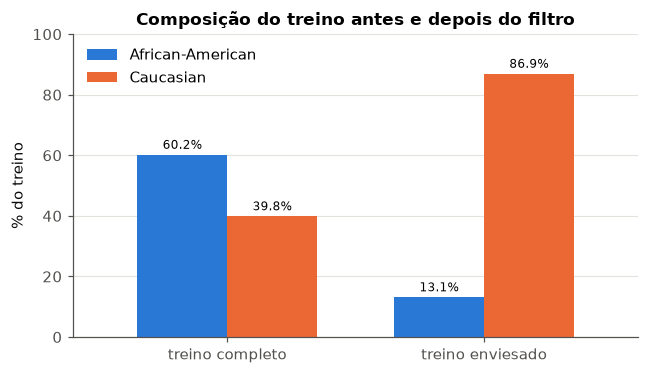

In [8]:
SEED = 42
train, test = split(df, SEED)
biased = make_biased_train(train, SEED)

comp = pd.DataFrame({"n_completo": train.race.value_counts(),
                     "n_enviesado": biased.race.value_counts()})
comp["%_completo"] = 100 * comp.n_completo / comp.n_completo.sum()
comp["%_enviesado"] = 100 * comp.n_enviesado / comp.n_enviesado.sum()
print(comp.round(1))
print(f"\nTaxa de reincidência no treino: completo = {train[TARGET].mean():.3f}, "
      f"enviesado = {biased[TARGET].mean():.3f}")

ax = comp[["%_completo", "%_enviesado"]].T.plot.bar(
    rot=0, figsize=(6, 3.5), width=0.7, color=[COLORS[g] for g in comp.index]
)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_xticklabels(["treino completo", "treino enviesado"])
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)
ax.legend(title=None)
ax.set_ylabel("% do treino")
ax.set_title("Composição do treino antes e depois do filtro")
plt.tight_layout()
save_fig(ax.figure, "composicao_treino")
plt.show()

Perfil dos afro-americanos que ficam no treino em cada método (semente 42):

In [9]:
def kept_profile(sampling):
    b = make_biased_train(train, SEED, sampling=sampling)
    return b[b.race == GROUP_SUB][["priors_count", TARGET]].mean()


profile = {name: kept_profile(name) for name in SAMPLERS}
profile["grupo completo"] = train[train.race == GROUP_SUB][["priors_count", TARGET]].mean()
pd.DataFrame(profile).T.rename(columns={TARGET: "taxa_reincidencia"}).style.format(
    {"priors_count": "{:.2f}", "taxa_reincidencia": "{:.1%}"}
)

,priors_count,taxa_reincidencia
aleatorio,3.93,49.1%
poucos_antecedentes,0.53,34.7%
muitos_antecedentes,13.24,75.7%
reincidentes_x3,5.27,76.6%
reincidentes_x10,5.97,94.1%
grupo completo,4.22,52.3%


## 3. Exemplo do efeito

Dois modelos iguais (regressão logística, sem `race`): um treinado com o treino completo e outro com o treino filtrado por sorteio. Os dois são testados no mesmo teste.

Duas explicações possíveis:

- **H1:** o modelo aprende pior o grupo subrepresentado, e só ele piora.
- **H2:** subrepresentar o grupo muda a taxa de reincidência do treino, o modelo ajusta o risco médio e o corte de 0,5, e os dois grupos mudam juntos.

In [10]:
cols = features(False)
base = build_model("logistic", False).fit(train[cols], train[TARGET])
bias = build_model("logistic", False).fit(biased[cols], biased[TARGET])

y_test, race_test = test[TARGET].to_numpy(), test.race.to_numpy()
example = pd.concat({
    "baseline": metrics_by_group(y_test, base.predict(test[cols]), race_test),
    "enviesado": metrics_by_group(y_test, bias.predict(test[cols]), race_test),
}, names=["modelo"])[["n", "taxa_base", "TPR", "FNR", "FPR", "precisao", "acuracia"]]
fmt_rates(example, "Uma semente (42): baseline vs enviesado")

Probabilidade média prevista por grupo. A queda ocorre só no grupo subrepresentado (H1) ou nos dois (H2)? Mudanças pequenas aqui já alteram bastante o TPR e o FPR, porque muitos casos ficam perto do corte de 0,5. Este exemplo usa uma só semente, e a seção 4 repete tudo com várias.

In [11]:
p_base = pd.Series(base.predict_proba(test[cols])[:, 1], index=test.index)
p_bias = pd.Series(bias.predict_proba(test[cols])[:, 1], index=test.index)
prob = pd.DataFrame({
    "taxa real": test.groupby("race")[TARGET].mean(),
    "prob. média, baseline": p_base.groupby(test.race).mean(),
    "prob. média, enviesado": p_bias.groupby(test.race).mean(),
})
prob.style.format("{:.1%}")

,taxa real,"prob. média, baseline","prob. média, enviesado"
race,,,
African-American,52.4%,52.2%,51.1%
Caucasian,39.1%,39.9%,39.2%


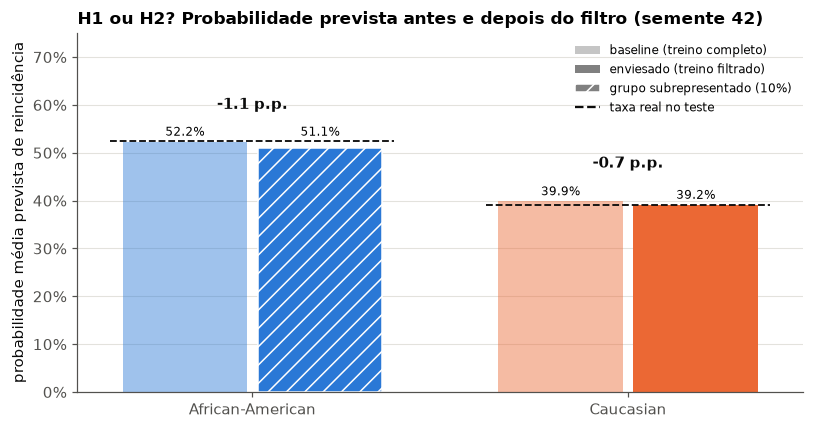

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4))
width = 0.36
for k, group in enumerate(GROUPS):
    for j, (label, col) in enumerate([("baseline", "prob. média, baseline"), ("enviesado", "prob. média, enviesado")]):
        x = k + (j - 0.5) * width
        v = prob.loc[group, col]
        striped = label == "enviesado" and group == GROUP_SUB
        ax.bar(x, v, width * 0.92, color=COLORS[group], alpha=0.45 if label == "baseline" else 1,
               hatch="//" if striped else None, edgecolor="white" if striped else None)
        ax.text(x, max(v, prob.loc[group, "taxa real"]) + 0.012, f"{v:.1%}", ha="center", fontsize=8)
    drop = prob.loc[group, "prob. média, enviesado"] - prob.loc[group, "prob. média, baseline"]
    top = max(prob.loc[group, "prob. média, baseline"], prob.loc[group, "prob. média, enviesado"])
    ax.text(k, top + 0.07, f"{100 * drop:+.1f} p.p.", ha="center", fontsize=10, fontweight="bold", color=INK)
    real = prob.loc[group, "taxa real"]
    ax.plot([k - width * 1.05, k + width * 1.05], [real, real], color=INK, linestyle="--", linewidth=1.2)
ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels(GROUPS)
ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("probabilidade média prevista de reincidência")
ax.set_title("H1 ou H2? Probabilidade prevista antes e depois do filtro (semente 42)", loc="left")
ax.legend(handles=[
    Patch(facecolor="gray", alpha=0.45, label="baseline (treino completo)"),
    Patch(facecolor="gray", label="enviesado (treino filtrado)"),
    Patch(facecolor="gray", edgecolor="white", hatch="//", label="grupo subrepresentado (10%)"),
    Line2D([], [], color=INK, linestyle="--", label="taxa real no teste"),
], loc="upper right", fontsize=8)
fig.tight_layout()
save_fig(fig, "hipotese_h1_h2")
plt.show()

## 4. Todos os casos

Cada caso treina um **baseline** (treino completo) e um modelo **enviesado** (treino filtrado), testa os dois no mesmo teste e repete com `N_SEEDS` sementes. Os casos variam o modelo, o uso de `race`, o grupo subrepresentado e o método de amostragem. Na primeira tabela, o grupo subrepresentado aparece com `(10%)` ao lado do nome, e a tabela de variações usa o mesmo formato. Em todos os casos o subrepresentado são os afro-americanos, exceto no A2, que subrepresenta os caucasianos.

In [13]:
CASES = {
    "A1 sorteio | logística": dict(),
    "A2 sorteio | logística, subrepresenta caucasianos": dict(sub=GROUP_REF),
    "A3 sorteio | floresta": dict(model="forest"),
    "A4 sorteio | logística + race": dict(use_race=True),
    "A5 sorteio | floresta + race": dict(model="forest", use_race=True),
    "B1 poucos antecedentes | logística": dict(sampling="poucos_antecedentes"),
    "B2 poucos antecedentes | floresta + race": dict(sampling="poucos_antecedentes", model="forest", use_race=True),
    "C1 muitos antecedentes | logística": dict(sampling="muitos_antecedentes"),
    "C2 muitos antecedentes | floresta + race": dict(sampling="muitos_antecedentes", model="forest", use_race=True),
    "D1 reincidentes x3 | logística": dict(sampling="reincidentes_x3"),
    "D2 reincidentes x10 | logística": dict(sampling="reincidentes_x10"),
    "D3 reincidentes x3 | floresta + race": dict(sampling="reincidentes_x3", model="forest", use_race=True),
    "D4 reincidentes x10 | floresta + race": dict(sampling="reincidentes_x10", model="forest", use_race=True),
}


def run_case(case, seed, model="logistic", use_race=False, sampling="aleatorio", sub=GROUP_SUB):
    cols = features(use_race)
    train, test = split(df, seed)
    biased = make_biased_train(train, seed, sub, sampling)
    y, race = test[TARGET].to_numpy(), test.race.to_numpy()

    rows = []
    for label, data in [("baseline", train), ("enviesado", biased)]:
        fitted = build_model(model, use_race).fit(data[cols], data[TARGET])
        out = metrics_by_group(y, fitted.predict(test[cols]), race).reset_index()
        out["papel"] = np.where(out.grupo == sub, "subrepresentado", np.where(out.grupo == "Geral", "geral", "outro"))
        out["caso"], out["modelo"], out["seed"] = case, label, seed
        rows.append(out)
    return pd.concat(rows, ignore_index=True)


res = pd.concat(
    [run_case(case, seed, **spec) for case, spec in CASES.items() for seed in range(N_SEEDS)],
    ignore_index=True,
)

Taxas médias por grupo, antes e depois do filtro:

In [14]:
by_group = res[res.papel != "geral"].pivot_table(
    index=["caso", "papel"], columns="modelo", values=["FNR", "FPR"]
)
by_group = by_group.reindex(pd.MultiIndex.from_product([list(CASES), ["subrepresentado", "outro"]]))


def group_label(caso, papel):
    """Nome do grupo; o subrepresentado leva a fração que ficou no treino ao lado do nome."""
    under = CASES[caso].get("sub", GROUP_SUB)
    other = GROUP_REF if under == GROUP_SUB else GROUP_SUB
    return f"{under} ({FRAC:.0%})" if papel == "subrepresentado" else other


by_group.index = pd.MultiIndex.from_tuples([(caso, group_label(caso, papel)) for caso, papel in by_group.index])
shown = by_group[[("FNR", "baseline"), ("FNR", "enviesado"), ("FPR", "baseline"), ("FPR", "enviesado")]]
tidy(
    shown.style.format("{:.1%}").background_gradient(cmap="Greys", vmin=0, vmax=1.2, axis=None)
    .set_caption(f"Taxa de erro média em {N_SEEDS} sementes. ({FRAC:.0%}) marca o grupo subrepresentado."),
    split_at=2, breaks=range(0, len(shown), 2),
)

Variação (enviesado menos baseline): média das sementes, com o desvio-padrão entre parênteses. Cada caso tem uma linha por grupo, e `(10%)` marca o subrepresentado. A coluna `Disparidade` é a variação do grupo subrepresentado menos a do outro grupo (a linha de cima menos a de baixo).

Leitura das cores: **vermelho** = o grupo erra mais depois do filtro (ou o grupo subrepresentado piorou mais que o outro), **azul** = erra menos. Célula **em negrito e colorida** = variação maior que 2 desvios entre sementes. Célula **cinza** = dentro do ruído, pode ser acaso.

In [15]:
wide = res[res.papel != "geral"].pivot_table(
    index=["caso", "seed", "papel"], columns="modelo", values=["FNR", "FPR"]
)
delta = (wide.xs("enviesado", axis=1, level=1) - wide.xs("baseline", axis=1, level=1)).unstack("papel")
for m in ["FNR", "FPR"]:
    delta[(m, "diferença")] = delta[(m, "subrepresentado")] - delta[(m, "outro")]

order = [(m, p) for m in ["FNR", "FPR"] for p in ["subrepresentado", "outro", "diferença"]]
mean = delta.groupby("caso").mean()[order].reindex(list(CASES))
std = delta.groupby("caso").std()[order].reindex(list(CASES))
from IPython.display import HTML

cmap = plt.get_cmap("RdBu_r")
CSS = """
<style>
.vt { border-collapse: collapse; }
.vt th, .vt td { padding: 4px 10px; text-align: center; white-space: nowrap; min-width: 8em; }
.vt th.caso, .vt th.grupo { text-align: left; }
.vt th.caso { vertical-align: middle; }
.vt tr.first > * { border-top: 1px solid rgba(128, 128, 128, 0.6); }
.vt .split { border-left: 1px solid rgba(128, 128, 128, 0.6); }
.vt .disp { border-left: 1px dotted rgba(128, 128, 128, 0.6); vertical-align: middle; }
.vt caption { caption-side: top; text-align: left; font-weight: bold; padding-bottom: 6px; }
</style>
"""


def cell(caso, metric, papel, classes="", rowspan=1):
    """<td> de uma variação: colorida e em negrito se passa de 2 desvios entre sementes, cinza se for ruído."""
    m, s = mean.loc[caso, (metric, papel)], std.loc[caso, (metric, papel)]
    if abs(m) > 2 * s:
        red, green, blue, _a = cmap(0.5 + 0.5 * np.clip(m / 0.3, -1, 1))
        dark = (0.299 * red + 0.587 * green + 0.114 * blue) < 0.5
        style = (f"background: rgba({int(red*255)}, {int(green*255)}, {int(blue*255)}, 0.85); "
                 f"color: {'white' if dark else 'black'}; font-weight: bold")
    else:
        style = "color: #8a8985"
    return f'<td class="{classes}" rowspan="{rowspan}" style="{style}">{m:+.3f} ({s:.3f})</td>'


body = []
for caso in mean.index:
    top = [f'<th class="caso" rowspan="2">{caso}</th>', f'<th class="grupo">{group_label(caso, "subrepresentado")}</th>']
    bottom = [f'<th class="grupo">{group_label(caso, "outro")}</th>']
    for metric in ["FNR", "FPR"]:
        top.append(cell(caso, metric, "subrepresentado", "split" if metric == "FPR" else ""))
        top.append(cell(caso, metric, "diferença", "disp", rowspan=2))
        bottom.append(cell(caso, metric, "outro", "split" if metric == "FPR" else ""))
    body.append(f'<tr class="first">{"".join(top)}</tr><tr>{"".join(bottom)}</tr>')

header = (
    '<tr><th colspan="2" rowspan="2"></th><th colspan="2">FNR</th><th colspan="2" class="split">FPR</th></tr>'
    '<tr><th>Variação</th><th>Disparidade</th><th class="split">Variação</th><th>Disparidade</th></tr>'
)
HTML(CSS + f'<table class="vt"><caption>Variação da taxa de erro: média (desvio) em {N_SEEDS} sementes</caption>'
     f'<thead>{header}</thead><tbody>{"".join(body)}</tbody></table>')

Os mesmos resultados em gráficos, uma família por bloco e um caso por linha. À esquerda fica o **FNR** (reincidentes que passaram batido) e à direita o **FPR** (não reincidentes marcados como alto risco). Em cada gráfico, a primeira barra de cada cor é o baseline e a segunda é o enviesado. A barra listrada é o grupo subrepresentado, com 10% dos dados, por isso só existe no enviesado.

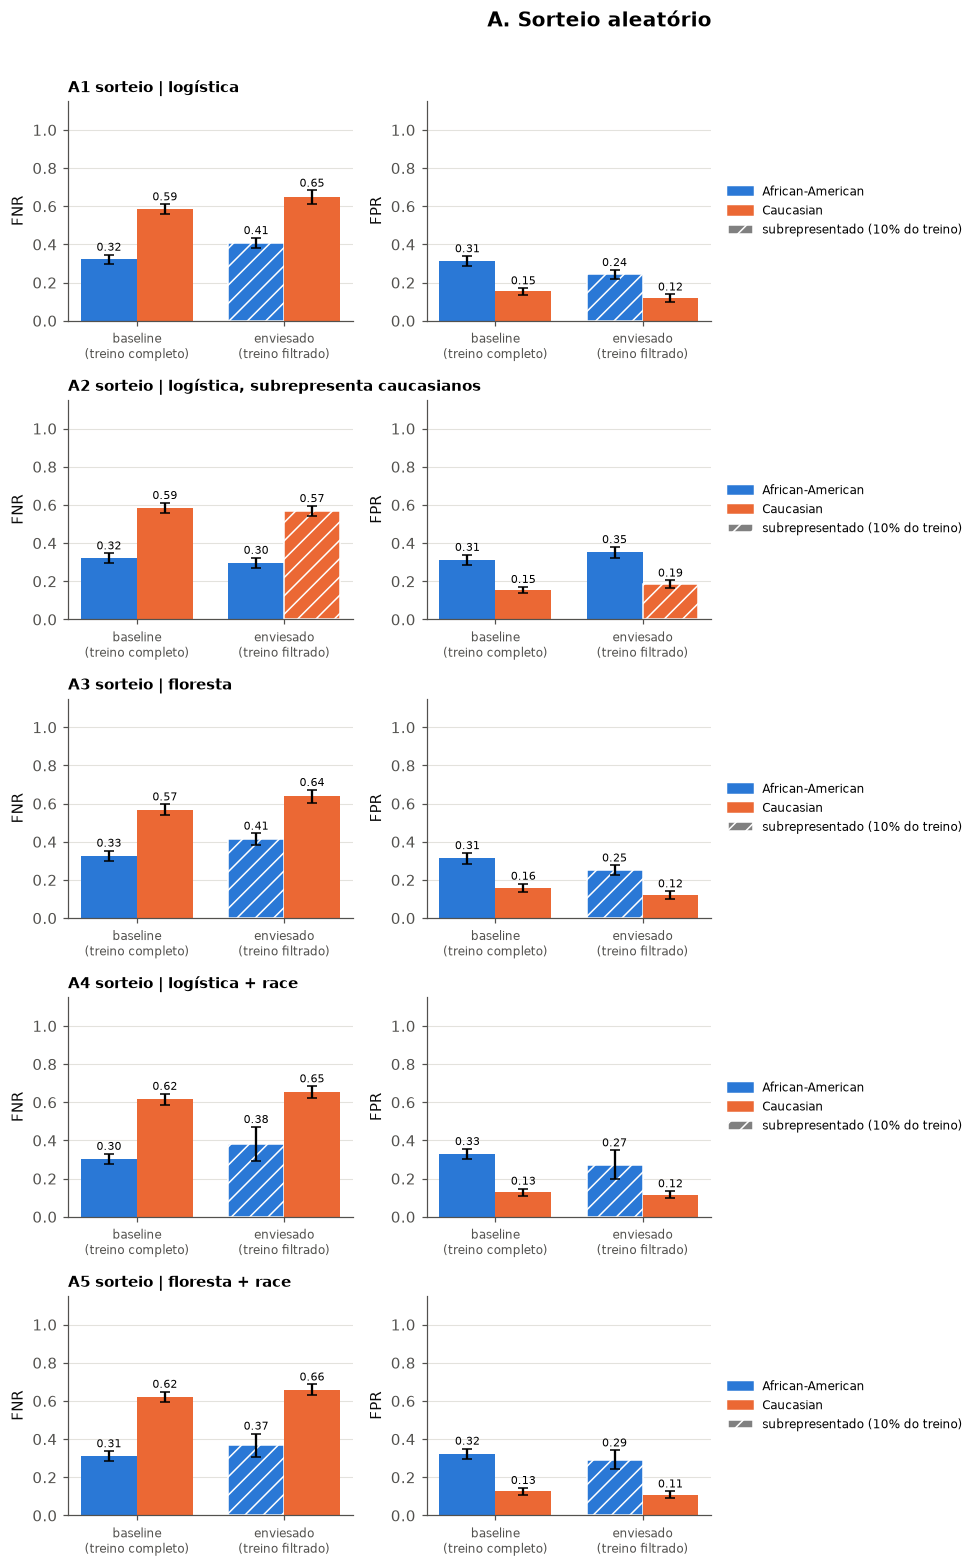

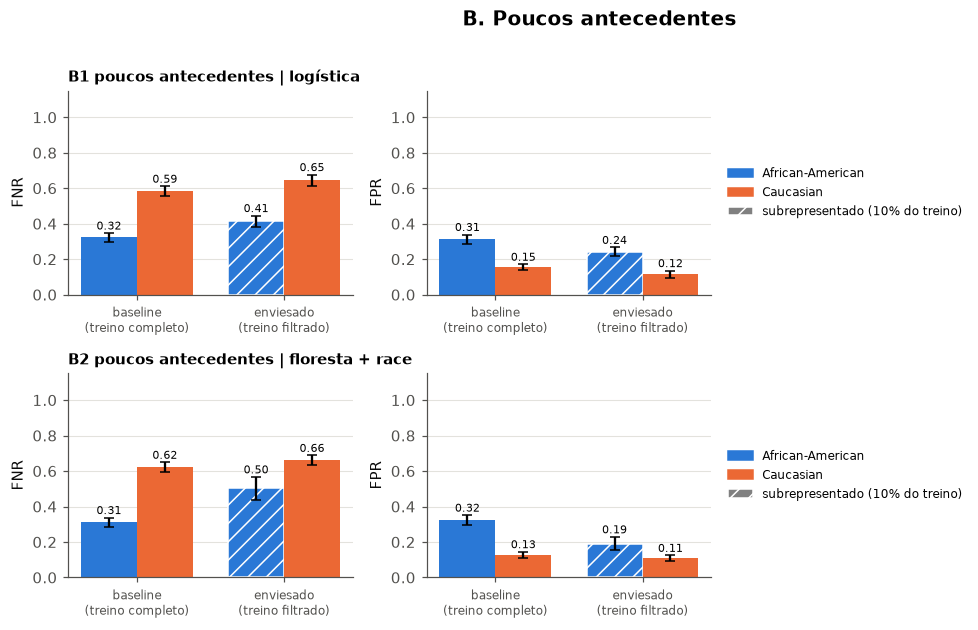

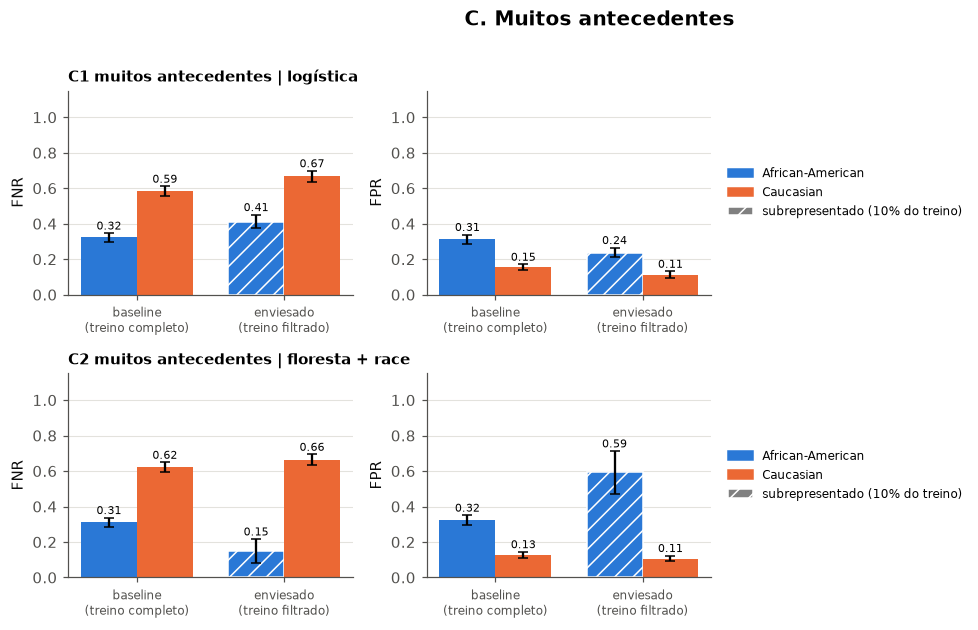

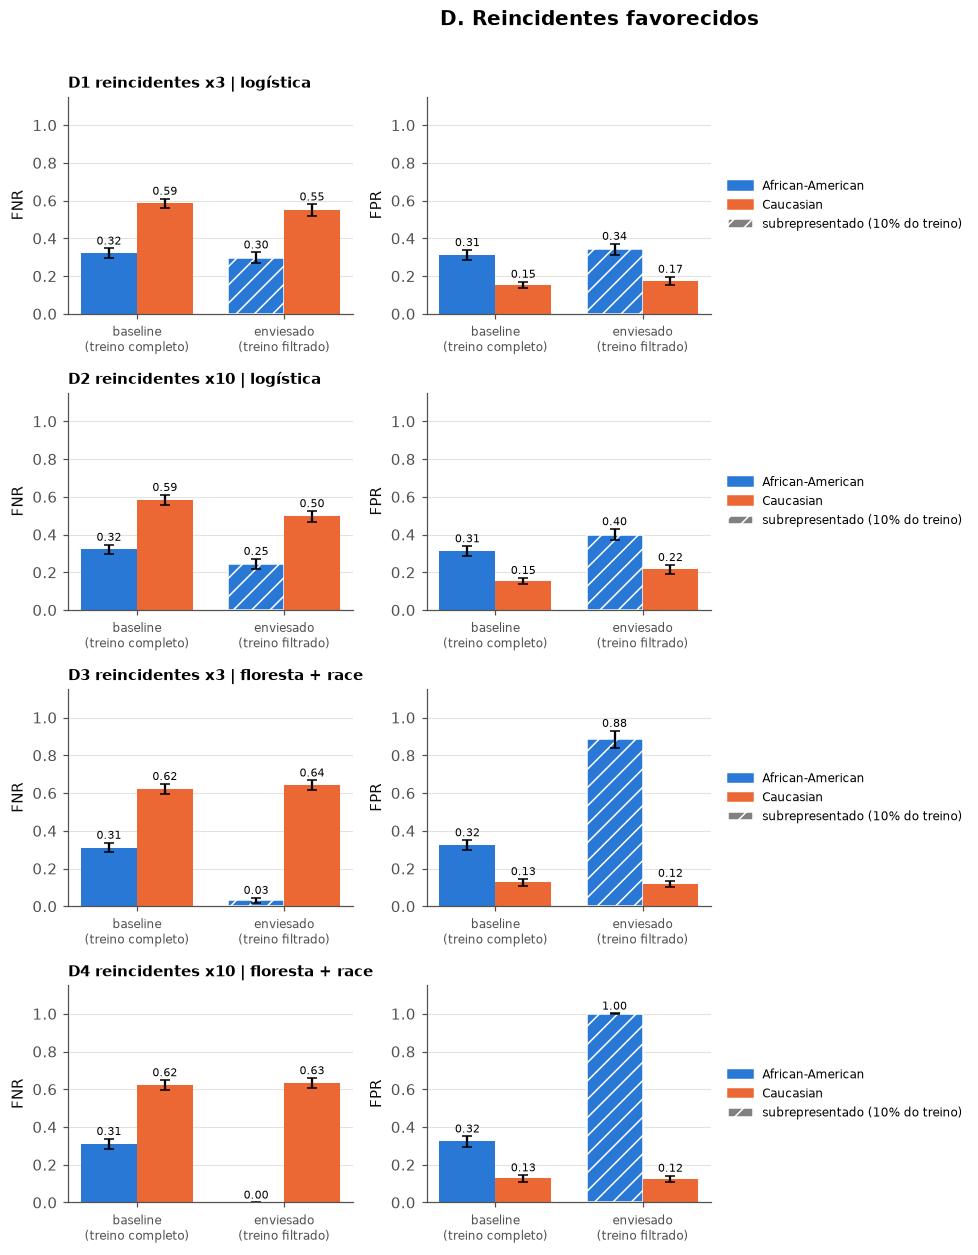

In [16]:
FAMILIES = {"A": "A. Sorteio aleatório", "B": "B. Poucos antecedentes",
            "C": "C. Muitos antecedentes", "D": "D. Reincidentes favorecidos"}
MODELS = ["baseline", "enviesado"]

stats = res[res.papel != "geral"].groupby(["caso", "grupo", "modelo"])[["FNR", "FPR"]].agg(["mean", "std"])
legend_items = [Patch(color=COLORS[g], label=g) for g in GROUPS]
legend_items.append(Patch(facecolor="gray", edgecolor="white", hatch="//", label="subrepresentado (10% do treino)"))


def plot_family(letter):
    cases = [c for c in CASES if c[0] == letter]
    fig, axes = plt.subplots(len(cases), 2, figsize=(11, 2.9 * len(cases)), squeeze=False)
    for row, case in zip(axes, cases):
        under = CASES[case].get("sub", GROUP_SUB)
        for ax, metric in zip(row, ["FNR", "FPR"]):
            for k, group in enumerate(GROUPS):
                for j, model in enumerate(MODELS):
                    v = stats.loc[(case, group, model), (metric, "mean")]
                    e = stats.loc[(case, group, model), (metric, "std")]
                    x = j + (k - 0.5) * 0.38
                    striped = model == "enviesado" and group == under
                    ax.bar(x, v, 0.38, yerr=e, capsize=3, color=COLORS[group],
                           hatch="//" if striped else None, edgecolor="white" if striped else None)
                    ax.text(x, v + e + 0.02, f"{v:.2f}", ha="center", fontsize=7)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["baseline\n(treino completo)", "enviesado\n(treino filtrado)"], fontsize=8)
            ax.set_ylim(0, 1.15)
            ax.set_ylabel(metric)
        row[0].set_title(case, loc="left", fontweight="bold", fontsize=10)
        row[1].legend(handles=legend_items, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.suptitle(FAMILIES[letter], fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 0.82, 0.97))
    save_fig(fig, f"familia_{letter}")
    plt.show()


for letter in FAMILIES:
    plot_family(letter)

Disparidade antes e depois do filtro, sempre como taxa dos afro-americanos menos taxa dos caucasianos (inclusive no A2). O ponto cinza é o baseline, a disparidade que já existe sem filtro. O ponto vermelho é o enviesado, e a seta mostra a mudança. Seta curta quer dizer que o filtro quase não alterou a disparidade. As barras vermelhas são o desvio entre sementes.

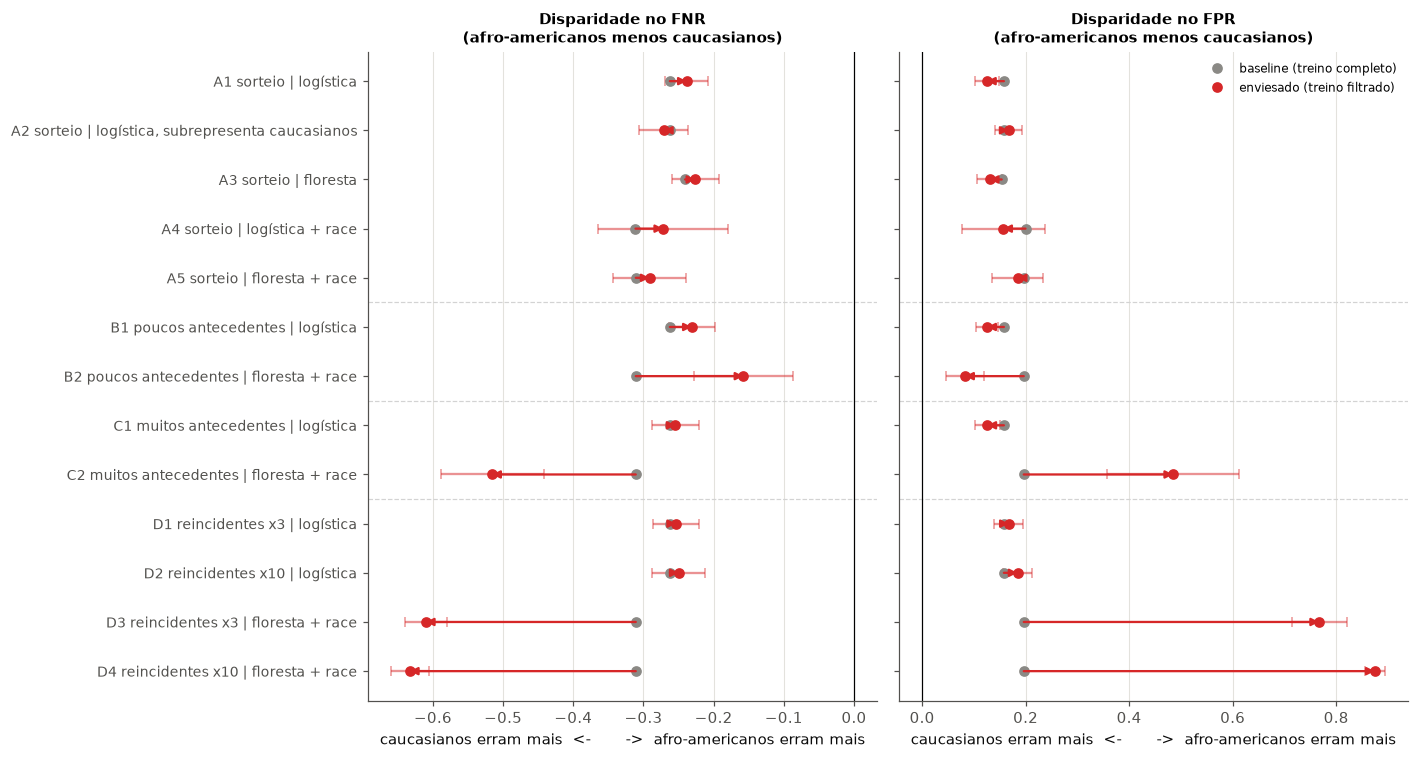

In [17]:
wide = res[res.papel != "geral"].pivot_table(
    index=["caso", "seed", "modelo"], columns="grupo", values=["FNR", "FPR"]
)
gap = wide.xs(GROUP_SUB, axis=1, level=1) - wide.xs(GROUP_REF, axis=1, level=1)
gap_mean = gap.groupby(["caso", "modelo"]).mean()
gap_std = gap.groupby(["caso", "modelo"]).std()

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for ax in axes:
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
case_names = list(CASES)
for ax, metric in zip(axes, ["FNR", "FPR"]):
    for i, case in enumerate(case_names):
        start = gap_mean.loc[(case, "baseline"), metric]
        end = gap_mean.loc[(case, "enviesado"), metric]
        err = gap_std.loc[(case, "enviesado"), metric]
        ax.annotate("", xy=(end, i), xytext=(start, i),
                    arrowprops=dict(arrowstyle="-|>", color="tab:red", lw=1.5, shrinkA=0, shrinkB=0))
        ax.errorbar(end, i, xerr=err, fmt="none", ecolor="tab:red", capsize=3, alpha=0.5)
        ax.plot(start, i, "o", color="#8a8985")
        ax.plot(end, i, "o", color="tab:red")
        if i and case[0] != case_names[i - 1][0]:
            ax.axhline(i - 0.5, color="lightgray", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Disparidade no {metric}\n(afro-americanos menos caucasianos)", fontsize=10)
    ax.set_xlabel("caucasianos erram mais  <-       ->  afro-americanos erram mais")

axes[0].set_yticks(range(len(case_names)))
axes[0].set_yticklabels(case_names, fontsize=9)
axes[0].invert_yaxis()
axes[1].legend(
    handles=[
        Line2D([], [], marker="o", color="#8a8985", linestyle="", label="baseline (treino completo)"),
        Line2D([], [], marker="o", color="tab:red", linestyle="", label="enviesado (treino filtrado)"),
    ],
    loc="upper right", fontsize=8,
)
plt.tight_layout()
save_fig(fig, "disparidade_setas")
plt.show()

## 5. Conclusões

1. **O tamanho do grupo não é o problema principal.** Com 10% dos afro-americanos escolhidos por sorteio, os dois grupos mudam quase igual (H2). A diferença entre os grupos só passa de 2 desvios nos casos B2, C2, D3 e D4, que combinam amostragem seletiva e floresta com `race`. Não há caso com floresta sem `race` sob amostragem seletiva, então não dá para separar o efeito de `race` do efeito da flexibilidade da floresta.
2. **O que o grupo subrepresentado guarda decide a direção do erro.** Quem fica com poucos antecedentes (B2) leva o modelo a deixar passar mais reincidentes (FNR +19 p.p.). Quem fica com muitos antecedentes (C2) ou só com reincidentes (D3, D4) leva o modelo a marcar quase todo o grupo como alto risco (FPR de 32% para 59%, 89% e 99,9%).
3. **A acurácia não mostra isso.** No exemplo da seção 3, a acurácia dos afro-americanos vai de 67,5% para 67,4%, enquanto o FNR sobe de 32,7% para 37,1% e o FPR cai de 32,4% para 27,8%. Só comparar FNR e FPR por grupo revela o deslocamento.
4. **A disparidade já existe antes do filtro.** No baseline do caso A1, o FNR é 32% (afro-americanos) contra 59% (caucasianos), e o FPR é 31% contra 15%. O filtro soma ou subtrai sobre esse ponto de partida (setas do último gráfico).
5. **Limites.** São só dois grupos, um corte fixo de 0,5 e uma divisão 70/30. Os métodos que escolhem pelo resultado (`reincidentes_x3` e `reincidentes_x10`) são uma suposição nossa. Não testamos calibração.

**Implicação prática:** auditar como o treino foi coletado (quem entrou e por quê), e não só quantas pessoas de cada grupo existem. E avaliar sempre as taxas de erro por grupo.